# 03 - Spatial analysis (Milestone 2 figures)

**Input:** `data/processed/strokes_all.csv`
**What it does:** produces three descriptive figures - shot frequency, mean opponent displacement by shot type, and cumulative displacement over the rally split by eventual winner vs loser - plus a sample summary table. This is the first test of the pressure hypothesis (it comes back null).
**Output:** `output/shot_frequency.png`, `output/mean_displacement_by_shot.png`, `output/displacement_winners_vs_losers.png`, `output/summary_stats.csv`

In [1]:
## --- path bootstrap: run from the repo root no matter where this is launched ---
## nbconvert and some editors set the working directory to the notebook's own
## folder. Walk up until we find the repo root (the folder containing data/),
## chdir there so relative data paths resolve, and put code/ on sys.path so the
## shared modules (utils.py, shot_translations.py) import cleanly.
import os, sys
_d = os.getcwd()
for _ in range(5):
    if os.path.isdir(os.path.join(_d, "data")):
        break
    _d = os.path.dirname(_d)
os.chdir(_d)
if os.path.join(_d, "code") not in sys.path:
    sys.path.insert(0, os.path.join(_d, "code"))
print("working directory:", os.getcwd())

working directory: /Users/aakankshvaidya/Desktop/qss20_final_project


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
## CONFIG
PROC_DIR = "data/processed"
OUT_DIR = "output"
os.makedirs(OUT_DIR, exist_ok=True)

In [4]:
strokes = pd.read_csv(os.path.join(PROC_DIR, "strokes_all.csv"))
print("rows:", len(strokes), " matches:", strokes["match_id"].nunique())

rows: 52356  matches: 58


## Figure 1 - shot frequency (descriptive baseline)

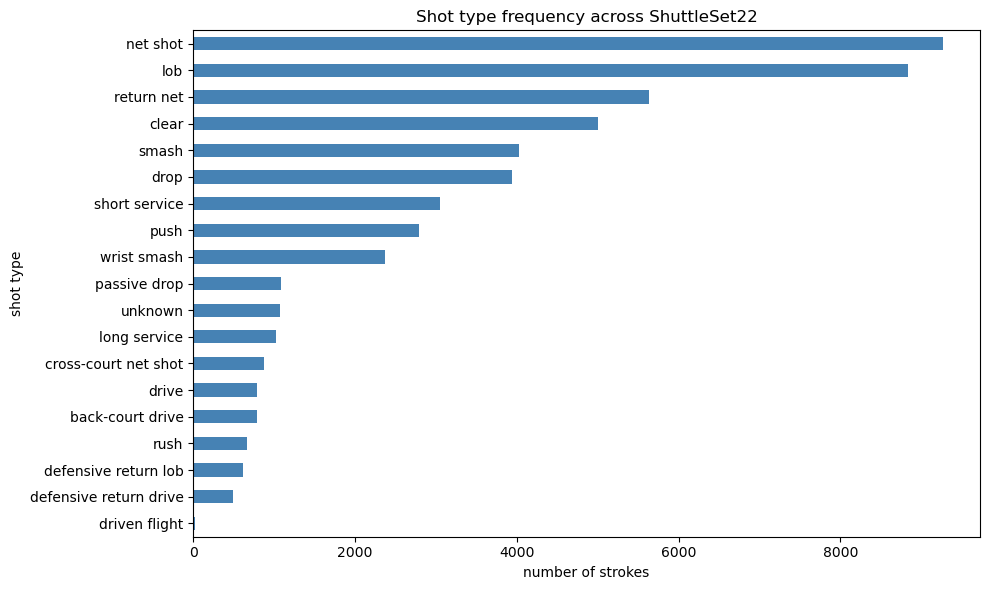

In [5]:
shot_counts = strokes["shot_type"].value_counts()
fig, ax = plt.subplots(figsize=(10, 6))
shot_counts.plot(kind="barh", ax=ax, color="steelblue")
ax.invert_yaxis()
ax.set_xlabel("number of strokes")
ax.set_ylabel("shot type")
ax.set_title("Shot type frequency across ShuttleSet22")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "shot_frequency.png"), dpi=150)
plt.show()

## Figure 2 - mean opponent displacement by shot type\nReframes shot selection from 'how often' to 'how much does it move the opponent'. Keeps shot types with n >= 30 for stability.

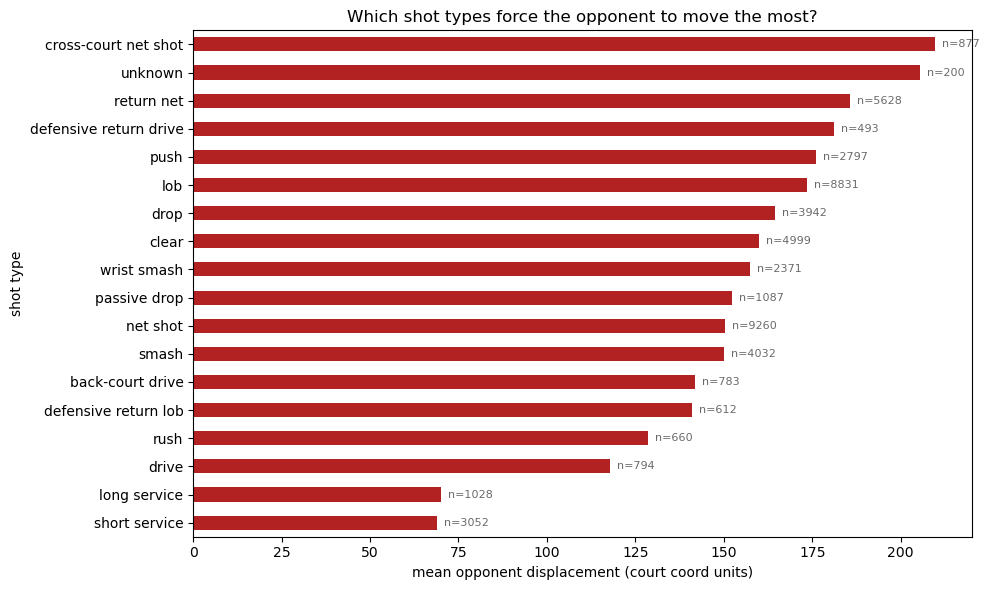

                        mean_displacement     n
shot_type                                      
short service                       68.82  3052
long service                        69.96  1028
drive                              117.77   794
rush                               128.63   660
defensive return lob               140.94   612
back-court drive                   141.92   783
smash                              150.11  4032
net shot                           150.24  9260
passive drop                       152.31  1087
wrist smash                        157.30  2371
clear                              160.05  4999
drop                               164.36  3942
lob                                173.53  8831
push                               175.97  2797
defensive return drive             181.08   493
return net                         185.64  5628
unknown                            205.53   200
cross-court net shot               209.71   877


In [6]:
disp_df = strokes.dropna(subset=["displacement", "shot_type"])
disp_by_type = (
    disp_df.groupby("shot_type")
    .agg(mean_displacement=("displacement", "mean"), n=("displacement", "size"))
    .sort_values("mean_displacement", ascending=True)
)
disp_by_type = disp_by_type[disp_by_type["n"] >= 30]

fig, ax = plt.subplots(figsize=(10, 6))
disp_by_type["mean_displacement"].plot(kind="barh", ax=ax, color="firebrick")
ax.set_xlabel("mean opponent displacement (court coord units)")
ax.set_ylabel("shot type")
ax.set_title("Which shot types force the opponent to move the most?")
for i, (val, n) in enumerate(zip(disp_by_type["mean_displacement"], disp_by_type["n"])):
    ax.text(val, i, f"  n={n}", va="center", fontsize=8, color="dimgray")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "mean_displacement_by_shot.png"), dpi=150)
plt.show()
print(disp_by_type.round(2))

## Figure 3 - cumulative displacement over the rally, winners vs losers\nThe central test: does the eventual rally winner apply more cumulative pressure? Capped at ball_round 20 where sample size thins.

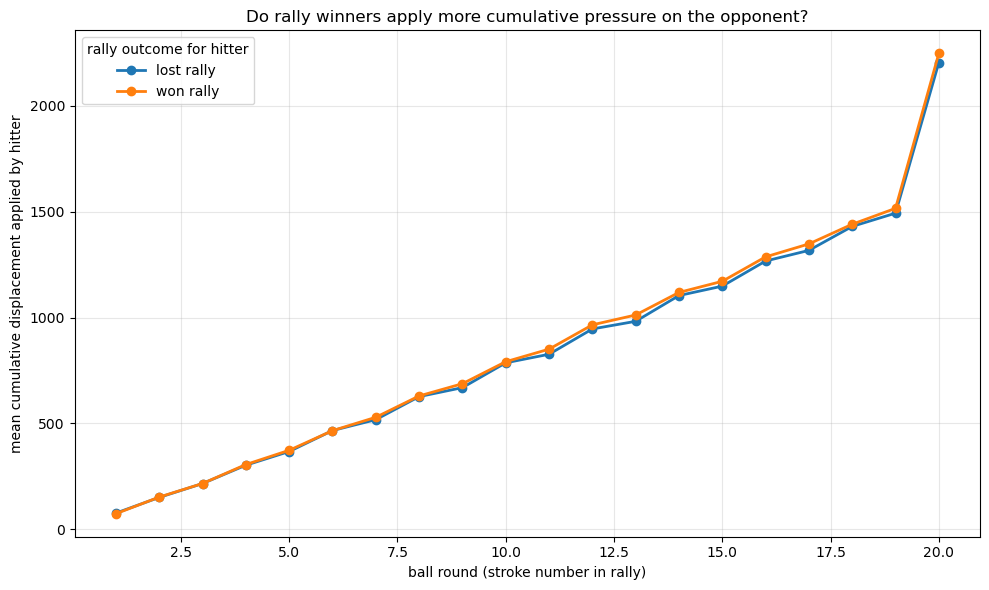

                   lost rally  won rally
ball_round_capped                       
1                       76.88      74.09
2                      151.09     152.59
3                      216.52     216.58
4                      303.02     306.18
5                      367.62     373.43
6                      466.60     466.14
7                      517.97     529.22
8                      626.76     629.84
9                      669.12     687.73
10                     786.31     791.54
11                     826.68     850.82
12                     946.15     965.50
13                     982.19    1012.05
14                    1103.81    1118.51
15                    1148.26    1171.12
16                    1266.78    1286.41
17                    1316.98    1347.53
18                    1430.09    1440.46
19                    1492.73    1515.45
20                    2203.80    2247.01


In [7]:
disp_df = strokes.dropna(subset=["displacement"]).copy()
disp_df = disp_df.sort_values(["match_id", "set_num", "rally", "ball_round"])
disp_df["cum_disp_by_hitter"] = (
    disp_df.groupby(["match_id", "set_num", "rally", "player"])["displacement"].cumsum()
)
disp_df["ball_round_capped"] = disp_df["ball_round"].clip(upper=20)

curve = (
    disp_df.groupby(["ball_round_capped", "hitter_won_rally"])["cum_disp_by_hitter"]
    .mean().reset_index()
)
curve_pivot = curve.pivot(index="ball_round_capped", columns="hitter_won_rally", values="cum_disp_by_hitter")
curve_pivot.columns = ["lost rally", "won rally"]

fig, ax = plt.subplots(figsize=(10, 6))
curve_pivot.plot(ax=ax, marker="o", linewidth=2)
ax.set_xlabel("ball round (stroke number in rally)")
ax.set_ylabel("mean cumulative displacement applied by hitter")
ax.set_title("Do rally winners apply more cumulative pressure on the opponent?")
ax.legend(title="rally outcome for hitter")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "displacement_winners_vs_losers.png"), dpi=150)
plt.show()
print(curve_pivot.round(2))

## Sample summary table

In [8]:
summary = pd.DataFrame({
    "metric": [
        "total strokes", "total rallies", "total matches",
        "mean displacement (all strokes)",
        "mean displacement (rallies won by hitter)",
        "mean displacement (rallies lost by hitter)",
    ],
    "value": [
        len(strokes),
        strokes.groupby(["match_id", "set_num", "rally"]).ngroups,
        strokes["match_id"].nunique(),
        round(strokes["displacement"].mean(), 2),
        round(strokes.loc[strokes["hitter_won_rally"] == True, "displacement"].mean(), 2),
        round(strokes.loc[strokes["hitter_won_rally"] == False, "displacement"].mean(), 2),
    ],
})
summary.to_csv(os.path.join(OUT_DIR, "summary_stats.csv"), index=False)
print(summary.to_string(index=False))

                                    metric    value
                             total strokes 52356.00
                             total rallies  4944.00
                             total matches    58.00
           mean displacement (all strokes)   155.96
 mean displacement (rallies won by hitter)   155.46
mean displacement (rallies lost by hitter)   156.44
